In [80]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/faizanhaider01/pensions-dataset/uncles_dataset.csv


In [81]:
df = pd.read_csv('/kaggle/input/datasets/faizanhaider01/pensions-dataset/uncles_dataset.csv')

In [82]:
df.sample(5)

,service_years_spend,pension,alive
210,8.2,5362,1
69,26.6,2000,0
26,9.7,2087,1
11,22.8,3160,1
71,22.6,2307,0


In [83]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [84]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state = 42)

In [85]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [86]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [87]:
model = Sequential([
    Dense(6, activation='relu', input_shape=(2,)),   # Hidden layer 1 (input: 2 columns)
    Dense(6, activation='relu'),                      # Hidden layer 2
    Dense(6, activation='relu'),                      # Hidden layer 3
    Dense(1, activation='sigmoid')                      # Output layer (regression -> linear)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [88]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [89]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_25 (Dense)                │ (None, 6)              │            18 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 6)              │            42 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 6)              │            42 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109 (436.00 B)

 Trainable params: 109 (436.00 B)

 Non-trainable params: 0 (0.00 B)

In [90]:
history = model.fit(
    X_train_scaled, y_train,
    epochs=20,
    batch_size=1,
    validation_split=0.2,
    verbose=1)

Epoch 1/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6146 - loss: 0.6808 - val_accuracy: 0.5208 - val_loss: 0.6899
Epoch 2/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6146 - loss: 0.6613 - val_accuracy: 0.5208 - val_loss: 0.6919
Epoch 3/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6146 - loss: 0.6464 - val_accuracy: 0.5208 - val_loss: 0.6978
Epoch 4/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6146 - loss: 0.6369 - val_accuracy: 0.5208 - val_loss: 0.7005
Epoch 5/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6146 - loss: 0.6332 - val_accuracy: 0.5208 - val_loss: 0.7004
Epoch 6/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6146 - loss: 0.6311 - val_accuracy: 0.5208 - val_loss: 0.7002
Epoch 7/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6146 - loss: 0.6285 - val_accuracy: 0.5208 - val_loss: 0.7023
Epoch 8/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6146 - loss: 0.6276 - val_accuracy: 0.

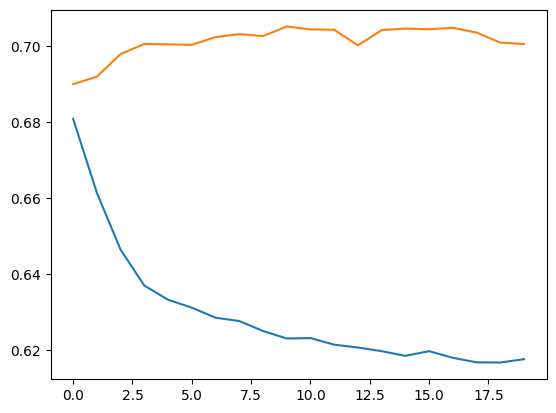

In [91]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

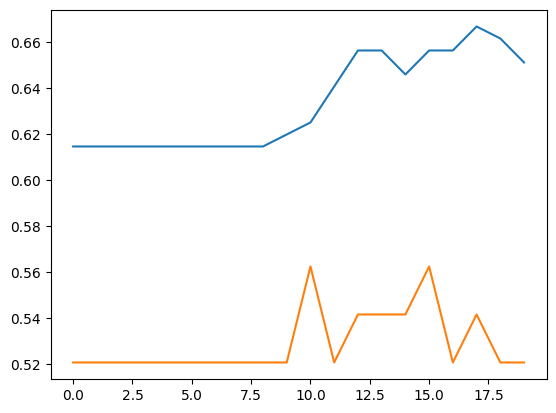

In [92]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

In [93]:
from tensorflow.keras.regularizers import l2

In [94]:
model2 = Sequential([
    Dense(6, activation='relu',kernel_regularizer=l2(0.01), input_shape=(2,)),   # Hidden layer 1 (input: 2 columns)
    Dense(6, activation='relu',kernel_regularizer=l2(0.01)),                      # Hidden layer 2
    Dense(6, activation='relu',kernel_regularizer=l2(0.01)),                      # Hidden layer 3
    Dense(1, activation='sigmoid')                      # Output layer (regression -> linear)
])

In [95]:
model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [96]:
historys = model2.fit(
    X_train_scaled, y_train,
    epochs=60,
    batch_size=1,
    validation_split=0.2,
    verbose=1,)

Epoch 1/60
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6458 - loss: 0.7987 - val_accuracy: 0.5625 - val_loss: 0.7958
Epoch 2/60
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6406 - loss: 0.7495 - val_accuracy: 0.5208 - val_loss: 0.7806
Epoch 3/60
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6354 - loss: 0.7235 - val_accuracy: 0.5208 - val_loss: 0.7731
Epoch 4/60
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6250 - loss: 0.7099 - val_accuracy: 0.5208 - val_loss: 0.7676
Epoch 5/60
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6354 - loss: 0.7009 - val_accuracy: 0.5208 - val_loss: 0.7620
Epoch 6/60
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6510 - loss: 0.6928 - val_accuracy: 0.5208 - val_loss: 0.7603
Epoch 7/60
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6458 - loss: 0.6887 - val_accuracy: 0.5417 - val_loss: 0.7547
Epoch 8/60
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6510 - loss: 0.6834 - val_accuracy: 0.

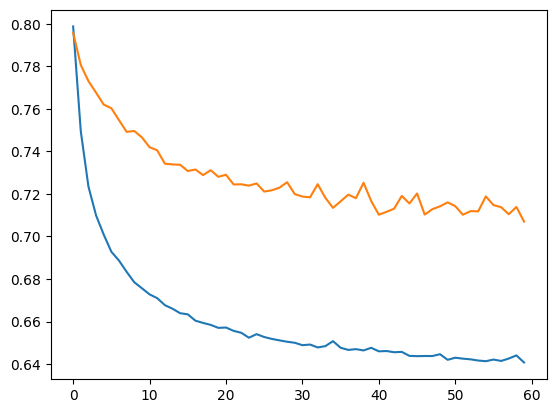

In [97]:
import matplotlib.pyplot as plt
plt.plot(historys.history['loss'])
plt.plot(historys.history['val_loss'])

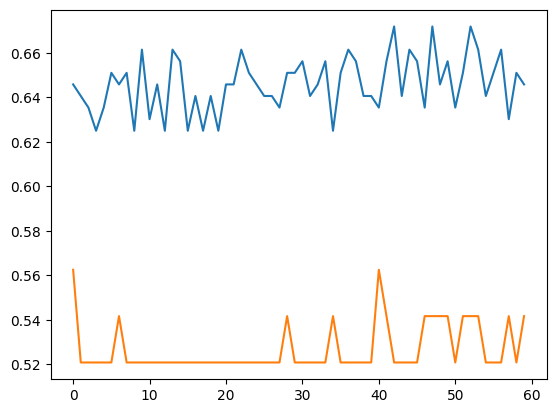

In [98]:
import matplotlib.pyplot as plt
plt.plot(historys.history['accuracy'])
plt.plot(historys.history['val_accuracy'])